In [15]:
#Importations
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (roc_auc_score,classification_report,accuracy_score,f1_score,recall_score)

In [2]:

df_imputed = pd.read_csv("../../data/weatherAUS_ForModel.csv")

In [3]:
X = df_imputed.drop(columns=["RainTomorrow", "Date", "SeasonName"], errors="ignore")
y = df_imputed["RainTomorrow"]

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (140091, 22)
Shape y: (140091,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (112072, 22)
Test size: (28019, 22)


In [5]:
nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)
y_prob_nb = nb_model.predict_proba(X_test)[:,1]
print("ROC-AUC Naive Bayes:", roc_auc_score(y_test, y_prob_nb))
print(classification_report(y_test, y_pred_nb))

ROC-AUC Naive Bayes: 0.8184545451195807
              precision    recall  f1-score   support

           0       0.88      0.87      0.87     21757
           1       0.56      0.59      0.58      6262

    accuracy                           0.81     28019
   macro avg       0.72      0.73      0.72     28019
weighted avg       0.81      0.81      0.81     28019



In [6]:
results_bayes = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted_Class": y_pred_nb,
    "Predicted_Probability": y_prob_nb
})
results_bayes.head(10)

,Actual,Predicted_Class,Predicted_Probability
0,0,0,0.403255
1,1,0,0.000976
2,0,0,0.122560
3,0,0,0.473002
4,0,0,0.003954
5,0,0,0.001266
6,0,0,0.088851
7,0,1,0.805545
8,0,0,0.001450
9,0,0,0.014244


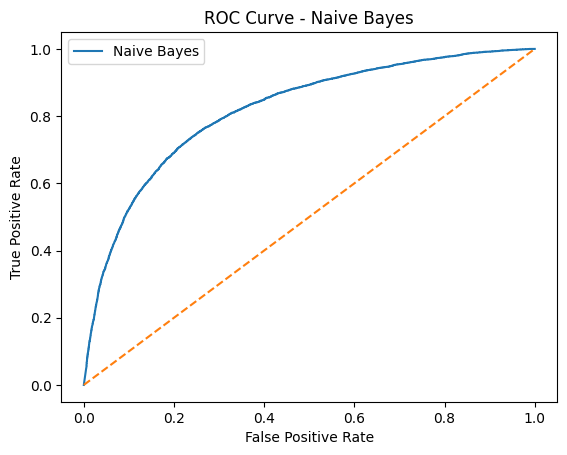

In [7]:
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)

plt.plot(fpr_nb, tpr_nb, label="Naive Bayes")
plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Naive Bayes")
plt.legend()
plt.show()

[[18881  2876]
 [ 2567  3695]]


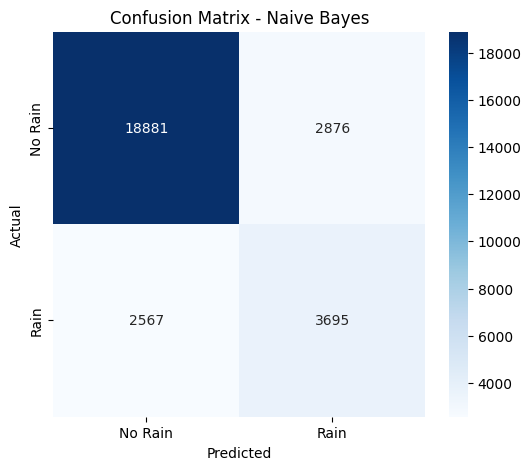

In [8]:
cm = confusion_matrix(y_test, y_pred_nb)
print(cm)
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Rain", "Rain"],
    yticklabels=["No Rain", "Rain"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Naive Bayes")

plt.show()

Le modèle Gaussian Naive Bayes obtient une performance correcte avec un ROC-AUC de 0.8187.
Cependant, ses performances restent limitées pour la classe minoritaire (pluie), en raison du déséquilibre des classes et de l’hypothèse d’indépendance conditionnelle des variables météorologiques.
La matrice de confusion révèle une bonne capacité du modèle à identifier les jours sans pluie (TN élevé).
Toutefois, le nombre de faux négatifs (2557) indique une difficulté à détecter certains épisodes pluvieux, ce qui limite la fiabilité du modèle pour des applications critiques.

Naive Bayes avec SMOTE

In [9]:
print("Avant SMOTE :")
print(y_train.value_counts())
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print("Après SMOTE :")
print(y_train_smote.value_counts())

Avant SMOTE :
RainTomorrow
0    87025
1    25047
Name: count, dtype: int64
Après SMOTE :
RainTomorrow
0    87025
1    87025
Name: count, dtype: int64


ROC-AUC avec SMOTE : 0.8175702678434738
              precision    recall  f1-score   support

           0       0.90      0.81      0.85     21757
           1       0.50      0.69      0.58      6262

    accuracy                           0.78     28019
   macro avg       0.70      0.75      0.72     28019
weighted avg       0.81      0.78      0.79     28019



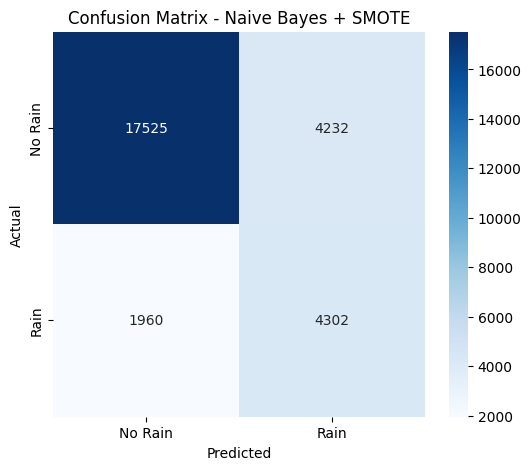

In [10]:
nb_model_smote = GaussianNB()

nb_model_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = nb_model_smote.predict(X_test)
y_prob_smote = nb_model_smote.predict_proba(X_test)[:,1]
from sklearn.metrics import roc_auc_score, classification_report

print("ROC-AUC avec SMOTE :", roc_auc_score(y_test, y_prob_smote))
print(classification_report(y_test, y_pred_smote))
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_smote = confusion_matrix(y_test, y_pred_smote)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_smote,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Rain", "Rain"],
    yticklabels=["No Rain", "Rain"]
)

plt.title("Confusion Matrix - Naive Bayes + SMOTE")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [11]:
results_bayes = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted_Class": y_pred_smote,
    "Predicted_Probability": y_prob_smote
})
results_bayes.head(10)

,Actual,Predicted_Class,Predicted_Probability
0,0,1,0.796431
1,1,0,0.003035
2,0,0,0.316588
3,0,1,0.818747
4,0,0,0.015972
5,0,0,0.003158
6,0,0,0.184746
7,0,1,0.959673
8,0,0,0.004022
9,0,0,0.048866


L’application de SMOTE a permis d’améliorer significativement la capacité du modèle à détecter les épisodes pluvieux (recall passant de 0.59 à 0.69), réduisant le nombre de faux négatifs. Cette amélioration se fait au prix d’une légère diminution de la précision globale, ce qui illustre le compromis classique entre précision et rappel dans un contexte de classes déséquilibrées.

Avec sample_weight (poids sur les observations)


================ Naive Bayes (sample_weight) ================

Ratio: 3.4744680001596997
ROC-AUC : 0.8184549891812629
              precision    recall  f1-score   support

           0       0.90      0.80      0.85     21757
           1       0.50      0.69      0.58      6262

    accuracy                           0.78     28019
   macro avg       0.70      0.75      0.71     28019
weighted avg       0.81      0.78      0.79     28019



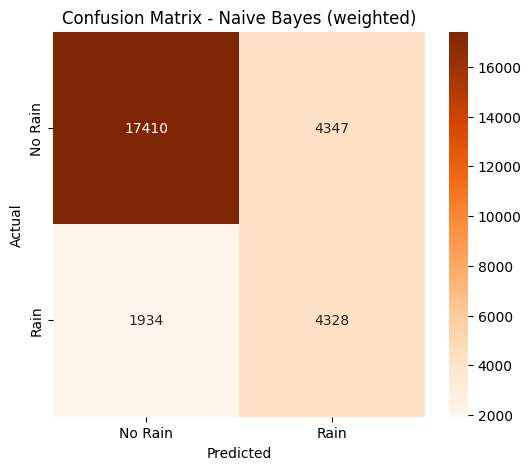

In [12]:
print("\n================ Naive Bayes (sample_weight) ================\n")

# Calcul du ratio
neg = np.sum(y_train == 0)
pos = np.sum(y_train == 1)
ratio = neg / pos

print("Ratio:", ratio)

# Création des poids pour chaque observation
sample_weights = np.where(y_train == 1, ratio, 1)

# Modèle
nb_weighted = GaussianNB()

# Entraînement avec pondération
nb_weighted.fit(X_train, y_train, sample_weight=sample_weights)

# Prédictions
y_prob_weight = nb_weighted.predict_proba(X_test)[:,1]

# Threshold ajustable

threshold = 0.45
y_pred_weight = (y_prob_weight >= threshold).astype(int)

# Résultats
print("ROC-AUC :", roc_auc_score(y_test, y_prob_weight))
print(classification_report(y_test, y_pred_weight))

# Matrice de confusion
cm_weight = confusion_matrix(y_test, y_pred_weight)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_weight,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["No Rain", "Rain"],
    yticklabels=["No Rain", "Rain"]
)

plt.title("Confusion Matrix - Naive Bayes (weighted)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [17]:
print("\n================ TABLEAU COMPARATIF NAIVE BAYES ================\n")

threshold = 0.45

results_nb = []


# NB NORMAL

y_proba_nb = nb_model.predict_proba(X_test)[:,1]
y_pred_nb = (y_proba_nb >= threshold).astype(int)

results_nb.append({
    "Model": "NB Normal",
    "Accuracy": accuracy_score(y_test, y_pred_nb),
    "F1": f1_score(y_test, y_pred_nb),
    "Recall": recall_score(y_test, y_pred_nb),
    "ROC-AUC": roc_auc_score(y_test, y_proba_nb)
})



#  NB + SMOTE

y_proba_smote = nb_model_smote.predict_proba(X_test)[:,1]
y_pred_smote = (y_proba_smote >= threshold).astype(int)

results_nb.append({
    "Model": "NB + SMOTE",
    "Accuracy": accuracy_score(y_test, y_pred_smote),
    "F1": f1_score(y_test, y_pred_smote),
    "Recall": recall_score(y_test, y_pred_smote),
    "ROC-AUC": roc_auc_score(y_test, y_proba_smote)
})



# NB + sample_weight

y_proba_weight = nb_weighted.predict_proba(X_test)[:,1]
y_pred_weight = (y_proba_weight >= threshold).astype(int)

results_nb.append({
    "Model": "NB + weighted",
    "Accuracy": accuracy_score(y_test, y_pred_weight),
    "F1": f1_score(y_test, y_pred_weight),
    "Recall": recall_score(y_test, y_pred_weight),
    "ROC-AUC": roc_auc_score(y_test, y_proba_weight)
})



df_nb = pd.DataFrame(results_nb)
print(df_nb)


================ TABLEAU COMPARATIF NAIVE BAYES ================

           Model  Accuracy        F1    Recall   ROC-AUC
0      NB Normal  0.802099  0.576427  0.602523  0.818455
1     NB + SMOTE  0.772833  0.579285  0.699776  0.817570
2  NB + weighted  0.775831  0.579501  0.691153  0.818455
